# *Clase 4 - Ejercicio de regresión logística - Ariel Tuñon*

## **Actividad 2:**

# **"Predecir qué sistema operativo utiliza un usuario"**

# Archivo utilizado como Dataset:

## *usuarios_win_mac_lin.csv*


## Preparación y organización de datos - Adquisición, Inspección y visualización de los datos


---



In [ ]:
import pandas as pd

# URL del archivo raw en GitHub
url = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase4/Datos/usuarios_win_mac_lin.csv"

# Leer el conjunto de datos
df = pd.read_csv(url)

# Mostrar las primeras 5 filas (head)
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


## Análisis Exploratorio de Datos (EDA)


---



# **Dimensiones, Resumen y análisis de valores nulos.**

In [ ]:
from IPython.display import display
import pandas as pd

print("\n" + "=" * 80)
print("ANÁLISIS INICIAL DEL DATASET — REGRESIÓN LOGÍSTICA")
print("=" * 80)
print("\n" * 2)
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" * 2)

resumen = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str),
    "No nulos": df.notna().sum(),
    "Nulos": df.isna().sum(),
    "% Nulos": (df.isna().mean() * 100).round(2),
    "Valores únicos": df.nunique()
})

display(resumen)
print("\n" * 2)

print("\n📈 Estadísticas descriptivas:")
display(df.describe(include="all").T)
print("\n" * 2)
from IPython.display import display
import pandas as pd

# Resumen de valores nulos
nulos = pd.DataFrame({
    "Variable": df.columns,
    "Valores nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2)
})

# Mostrar solo variables que tienen nulos
nulos = nulos[nulos["Valores nulos"] > 0]

print("\n" + "=" * 70)
print("🔎 ANÁLISIS DE VALORES NULOS")
print("=" * 70)

if nulos.empty:
    print("✅ No se encontraron valores nulos en el dataset.")
else:
    display(nulos)
    print("\n" * 2)



ANÁLISIS INICIAL DEL DATASET — REGRESIÓN LOGÍSTICA



Dimensiones: 170 filas × 5 columnas
Memoria: 0.01 MB





,Variable,Tipo,No nulos,Nulos,% Nulos,Valores únicos
duracion,duracion,float64,170,0,0.0,87
paginas,paginas,int64,170,0,0.0,8
acciones,acciones,int64,170,0,0.0,26
valor,valor,int64,170,0,0.0,43
clase,clase,int64,170,0,0.0,3






📈 Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
duracion,170.0,111.075729,202.453200,1.0,11.0,13.0,108.0,898.0
paginas,170.0,2.041176,1.500911,1.0,1.0,2.0,2.0,9.0
acciones,170.0,8.723529,9.136054,1.0,3.0,6.0,10.0,63.0
valor,170.0,32.676471,44.751993,1.0,8.0,20.0,36.0,378.0
clase,170.0,0.752941,0.841327,0.0,0.0,0.0,2.0,2.0






🔎 ANÁLISIS DE VALORES NULOS
✅ No se encontraron valores nulos en el dataset.


# **Balance de clases**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. CARGA DE DATOS Y CONFIGURACIÓN INICIAL
# ==============================================================================


# Mapeo de identificadores numéricos a nombres descriptivos
SO_MAP = {0: 'Windows (0)', 1: 'Macintosh (1)', 2: 'Linux (2)'}
SO_MAP_SHORT = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
PALETTE = {
    'Windows (0)': '#0078D4',
    'Macintosh (1)': '#A2AAAD',
    'Linux (2)': '#FCC624',
}

# Definir variable objetivo
objetivo = 'clase' if 'clase' in df.columns else df.columns[-1]

# ==============================================================================
# 2. ANÁLISIS DESCRIPTIVO Y BALANCE DE CLASES
# ==============================================================================
df_analisis = df.copy()
df_analisis['SO_Nombre'] = df_analisis[objetivo].map(SO_MAP)

balance = pd.DataFrame({
    'Cantidad': df_analisis['SO_Nombre'].value_counts(dropna=False),
    'Porcentaje (%)': df_analisis['SO_Nombre']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2),
})
balance['% Acumulado (%)'] = balance['Porcentaje (%)'].cumsum().round(2)

# Métricas de desbalance
clase_mayor = balance['Porcentaje (%)'].idxmax()
pct_mayor = balance['Porcentaje (%)'].max()
clase_menor = balance['Porcentaje (%)'].idxmin()
pct_menor = balance['Porcentaje (%)'].min()

cant_mayor = balance['Cantidad'].max()
cant_menor = balance['Cantidad'].min()
imbalance_ratio = cant_mayor / cant_menor if cant_menor > 0 else float('inf')

print("\n" * 2)
print('=' * 70)
print(f"BALANCE DE CLASES — VARIABLE: '{objetivo}' (Sistemas Operativos)")
print('=' * 70)
print(f'• Total de observaciones : {len(df):,}')
print(f'• Número de clases unique: {df[objetivo].nunique(dropna=False)}')
print(
    f'• Imbalance Ratio (IR)   : {imbalance_ratio:.2f}:1 (Mayoritaria vs'
    ' Minoritaria)\n'
)
print("\n" * 2)
print(balance)
print('\nRESUMEN DE DESBALANCE:')
print("\n" * 2)
print(
    f"  - Clase más frecuente   : '{clase_mayor}' con {cant_mayor:,} muestras"
    f' ({pct_mayor:.2f}%)'
)
print(
    f"  - Clase menos frecuente : '{clase_menor}' con {cant_menor:,} muestras"
    f' ({pct_menor:.2f}%)'
)

if imbalance_ratio == 1:
  print('  - Estado: 🟢 Totalmente balanceado.')
elif imbalance_ratio < 1.5:
  print('  - Estado: 🟢 Ligeramente desbalanceado (Aceptable).')
elif imbalance_ratio < 4:
  print('  - Estado: 🟡 Desbalance moderado.')
else:
  print('  - Estado: 🔴 Desbalance severo.')
print('=' * 70 + '\n')

# ==============================================================================
# 3. PREPARACIÓN DE DATOS Y ENTRENAMIENTO DEL MODELO
# ==============================================================================
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df[objetivo]

# División en entrenamiento (80%) y prueba (20%) manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado de características para optimizar la convergencia del algoritmo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento de Regresión Logística
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluaciones en test set
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'PRECISIÓN GLOBAL (ACCURACY): {acc*100:.2f}%\n')
print('REPORTE DE CLASIFICACIÓN:')
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Windows (0)', 'Macintosh (1)', 'Linux (2)'],
    )
)


# ==============================================================================
# 4. FUNCIÓN INTERACTIVA DE PREDICCIÓN PARA NUEVOS USUARIOS
# ==============================================================================
def predecir_sistema_operativo(
    duracion_sec, paginas_vistas, acciones, valor_acciones
):
  """Recibe métricas de Google Analytics y predice el SO del usuario."""
  datos = np.array([[duracion_sec, paginas_vistas, acciones, valor_acciones]])
  datos_scaled = scaler.transform(datos)

  pred = model.predict(datos_scaled)[0]
  probs = model.predict_proba(datos_scaled)[0]

  print('╔' + '═' * 52 + '╗')
  print('║           RESULTADO DE LA PREDICCIÓN            ║')
  print('╠' + '═' * 52 + '╣')
  print(f'  Predicción Principal: {SO_MAP_SHORT[pred]}')
  print('  ' + '─' * 48)
  print('  Probabilidades:')
  for clase_id, nombre in SO_MAP_SHORT.items():
    barra = '█' * int(probs[clase_id] * 20)
    print(f'    • {nombre:<15}: {probs[clase_id]*100:5.1f}% | {barra}')
  print('╚' + '═' * 52 + '╝\n')


# Ejemplo de uso con un usuario ficticio
print("Probando predicción para un usuario con: 120s duración, 4 páginas, 8 acciones, valor 18:")
predecir_sistema_operativo(
    duracion_sec=120, paginas_vistas=4, acciones=8, valor_acciones=18
)






BALANCE DE CLASES — VARIABLE: 'clase' (Sistemas Operativos)
• Total de observaciones : 170
• Número de clases unique: 3
• Imbalance Ratio (IR)   : 2.15:1 (Mayoritaria vs Minoritaria)




               Cantidad  Porcentaje (%)  % Acumulado (%)
SO_Nombre                                               
Windows (0)          86           50.59            50.59
Linux (2)            44           25.88            76.47
Macintosh (1)        40           23.53           100.00

RESUMEN DE DESBALANCE:



  - Clase más frecuente   : 'Windows (0)' con 86 muestras (50.59%)
  - Clase menos frecuente : 'Macintosh (1)' con 40 muestras (23.53%)
  - Estado: 🟡 Desbalance moderado.

PRECISIÓN GLOBAL (ACCURACY): 70.59%

REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

  Windows (0)       0.75      0.71      0.73        17
Macintosh (1)       1.00      0.38      0.55         8
    Linux (2)       0.60      1.00      0.75         9

     accuracy                           0

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


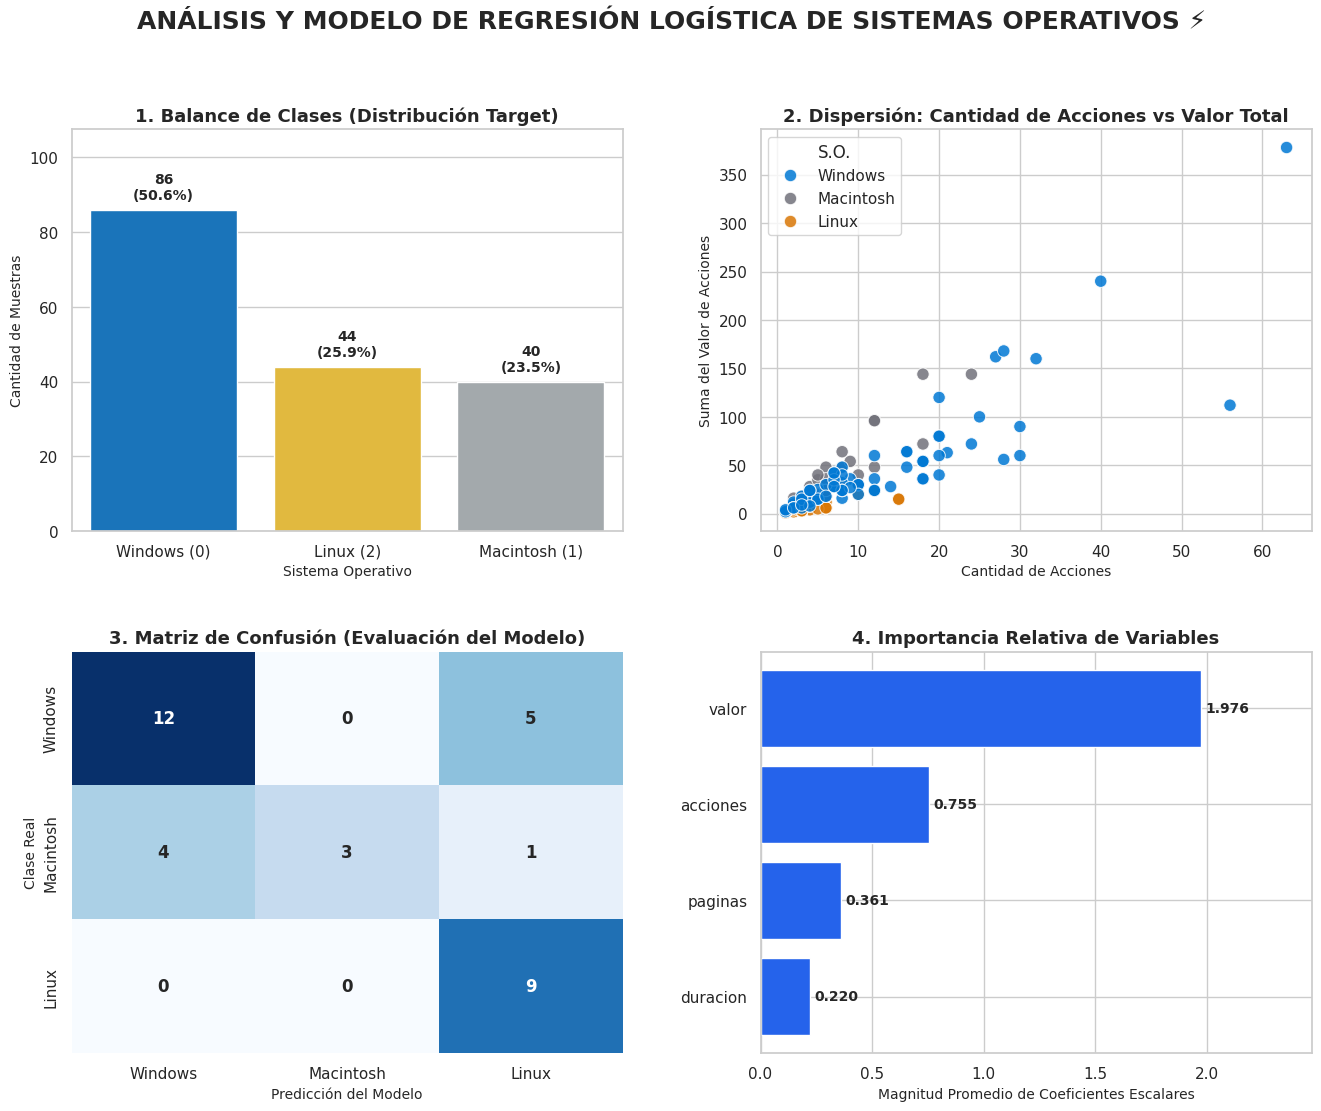

In [ ]:
# ==============================================================================
# 5. GENERACIÓN DEL DASHBOARD COMPLETO EN UN SOLO GRÁFICO
# ==============================================================================
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'ANÁLISIS Y MODELO DE REGRESIÓN LOGÍSTICA DE SISTEMAS OPERATIVOS ⚡',
    fontsize=18,
    fontweight='bold',
    y=0.98,
)
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# Subplot 1: Balance de Clases
ax1 = fig.add_subplot(gs[0, 0])
balance_plot = balance.reset_index().rename(columns={'index': 'SO_Nombre'})
sns.barplot(
    data=balance_plot,
    x='SO_Nombre',
    y='Cantidad',
    palette=PALETTE,
    ax=ax1,
    hue='SO_Nombre',
)
total = len(df)
for p in ax1.patches:
  height = p.get_height()
  if height > 0:
    percentage = (height / total) * 100
    ax1.annotate(
        f'{int(height):,}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )
ax1.set_title(
    '1. Balance de Clases (Distribución Target)', fontsize=13, fontweight='bold'
)
ax1.set_xlabel('Sistema Operativo', fontsize=10)
ax1.set_ylabel('Cantidad de Muestras', fontsize=10)
ax1.set_ylim(0, max(balance['Cantidad']) * 1.25)

# Subplot 2: Dispersión
ax2 = fig.add_subplot(gs[0, 1])
sns.scatterplot(
    data=df,
    x='acciones',
    y='valor',
    hue='clase',
    palette={0: '#0078D4', 1: '#71717A', 2: '#D97706'},
    ax=ax2,
    s=80,
    alpha=0.85,
)
ax2.set_title(
    '2. Dispersión: Cantidad de Acciones vs Valor Total',
    fontsize=13,
    fontweight='bold',
)
ax2.set_xlabel('Cantidad de Acciones', fontsize=10)
ax2.set_ylabel('Suma del Valor de Acciones', fontsize=10)
handles, _ = ax2.get_legend_handles_labels()
ax2.legend(
    handles, ['Windows', 'Macintosh', 'Linux'], title='S.O.', loc='upper left'
)

# Subplot 3: Matriz de Confusión
ax3 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax3,
    xticklabels=['Windows', 'Macintosh', 'Linux'],
    yticklabels=['Windows', 'Macintosh', 'Linux'],
    cbar=False,
    annot_kws={'size': 12, 'weight': 'bold'},
)
ax3.set_title(
    '3. Matriz de Confusión (Evaluación del Modelo)',
    fontsize=13,
    fontweight='bold',
)
ax3.set_xlabel('Predicción del Modelo', fontsize=10)
ax3.set_ylabel('Clase Real', fontsize=10)

# Subplot 4: Importancia de Variables
ax4 = fig.add_subplot(gs[1, 1])
coef_importance = np.abs(model.coef_).mean(axis=0)
feat_df = pd.DataFrame(
    {'Característica': X.columns, 'Importancia': coef_importance}
).sort_values('Importancia', ascending=True)

ax4.barh(feat_df['Característica'], feat_df['Importancia'], color='#2563EB')
for index, value in enumerate(feat_df['Importancia']):
  ax4.text(
      value + 0.02,
      index,
      f'{value:.3f}',
      va='center',
      fontweight='bold',
      fontsize=10,
  )
ax4.set_title(
    '4. Importancia Relativa de Variables', fontsize=13, fontweight='bold'
)
ax4.set_xlabel('Magnitud Promedio de Coeficientes Escalares', fontsize=10)
ax4.set_xlim(0, max(feat_df['Importancia']) * 1.25)

plt.show()

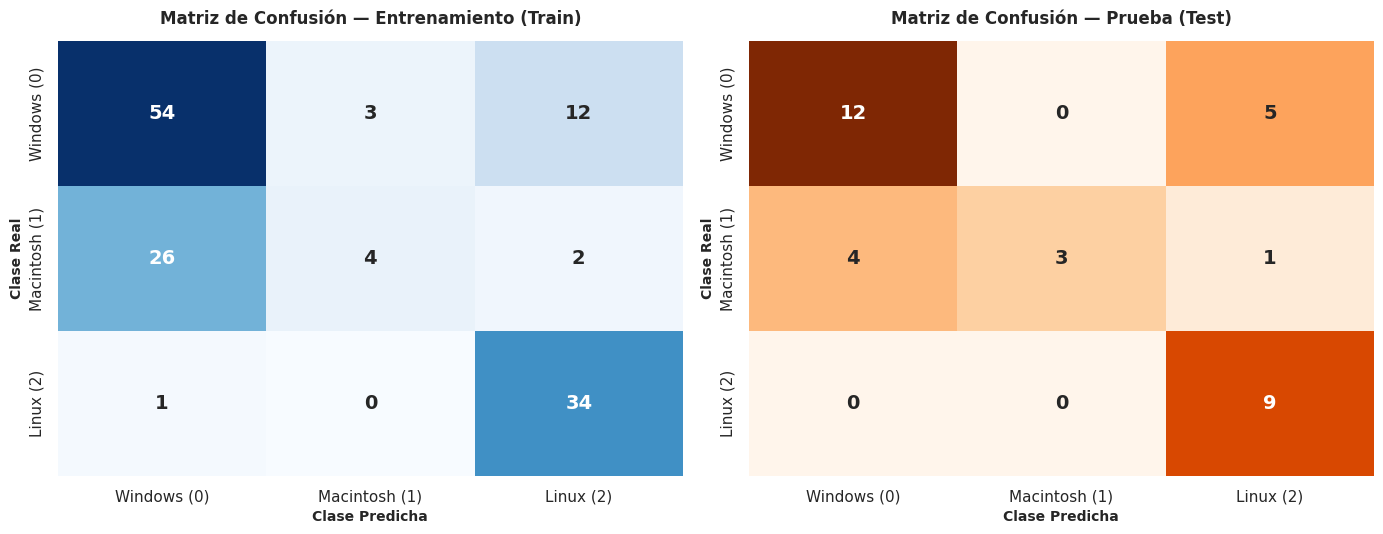

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# 1. Cargar datos
url = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase4/Datos/usuarios_win_mac_lin.csv"
df = pd.read_csv(url)

X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']
class_names = ['Windows (0)', 'Macintosh (1)', 'Linux (2)']

# 2. División en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalamiento de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenamiento del modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Obtener predicciones
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 6. Calcular matrices de confusión
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# 7. Graficar los dos Mapas de Calor
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Mapa de calor: Entrenamiento
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Matriz de Confusión — Entrenamiento (Train)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Clase Predicha', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=10, fontweight='bold')

# Mapa de calor: Prueba
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Matriz de Confusión — Prueba (Test)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Clase Predicha', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# **REPRESENTACIÓN GRÁFICA DE LA PREDICCIÓN REALIZADA POR EL MODELO**

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


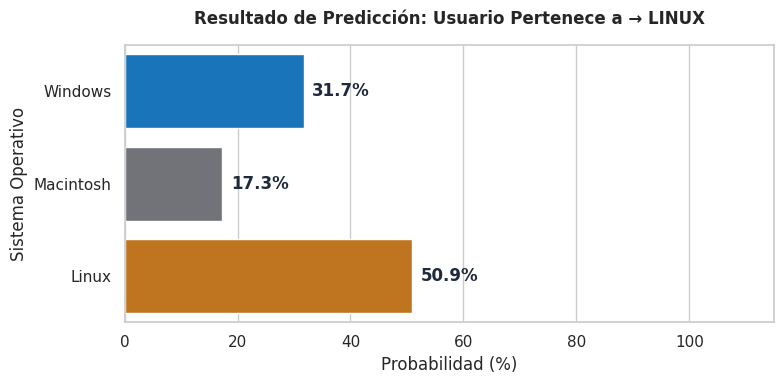





  EJEMPLO DE OTRA PREDICCIÓN, CON VARIOS USUARIOS NUEVOS – ARRAY DE VALORES  


 'duracion': [30, 200, 10, 450, 100] 
 'paginas': [1, 6, 1, 12, 3] 
 'acciones': [2, 18, 1, 35, 7] 
 'valor': [4, 45, 2, 120, 15] 






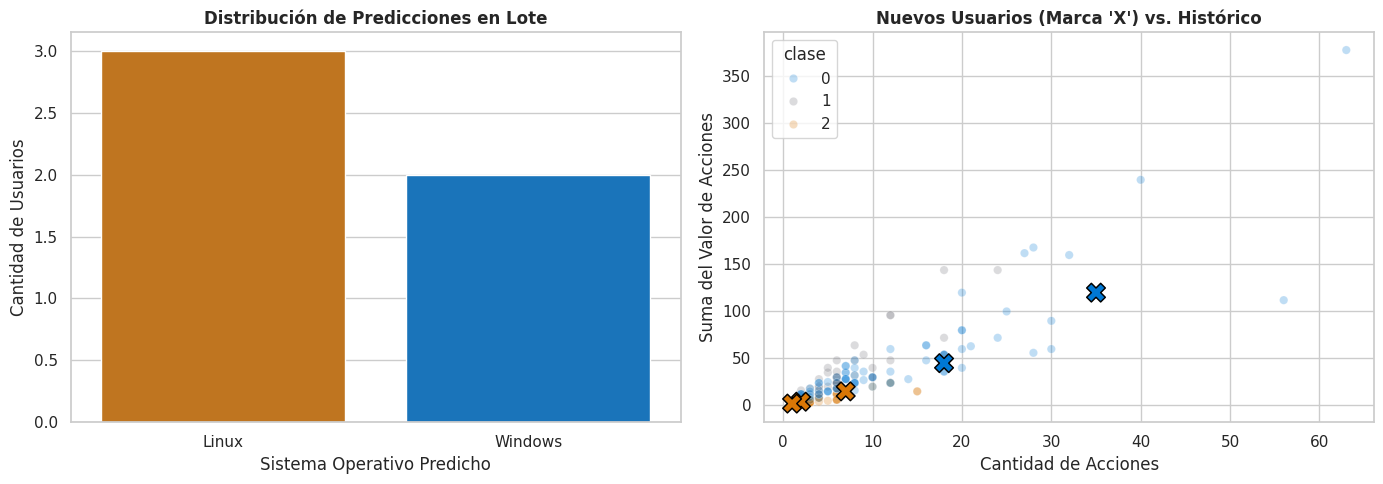

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def graficar_prediccion_usuario(duracion_sec, paginas_vistas, acciones, valor_acciones):
    # 1. Preparar y escalar datos
    datos = np.array([[duracion_sec, paginas_vistas, acciones, valor_acciones]])
    datos_scaled = scaler.transform(datos)

    # 2. Calcular probabilidades y predicción
    probs = model.predict_proba(datos_scaled)[0] * 100
    pred = model.predict(datos_scaled)[0]

    sistemas = ['Windows', 'Macintosh', 'Linux']
    colores = {'Windows': '#0078D4', 'Macintosh': '#71717A', 'Linux': '#D97706'}

    # 3. Crear DataFrame para Seaborn
    df_probs = pd.DataFrame({
        'Sistema Operativo': sistemas,
        'Probabilidad (%)': probs
    })

    # 4. Diseñar el gráfico
    plt.figure(figsize=(8, 4))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        data=df_probs,
        x='Probabilidad (%)',
        y='Sistema Operativo',
        palette=colores,
        hue='Sistema Operativo'
    )

    # Añadir las etiquetas con el porcentaje exacto sobre cada barra
    for p, prob in zip(ax.patches, probs):
        ax.annotate(f'{prob:.1f}%',
                    (prob + 1.5, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontweight='bold', color='#1E293B')

    plt.title(f"Resultado de Predicción: Usuario Pertenece a → {sistemas[pred].upper()}", fontweight='bold', pad=15)
    plt.xlim(0, 115)
    plt.tight_layout()
    plt.show()

# Ejemplo de uso con un usuario nuevo:
graficar_prediccion_usuario(duracion_sec=120, paginas_vistas=4, acciones=8, valor_acciones=18)


def graficar_predicciones_lote(df_nuevos):
    # 1. Escalar y predecir
    df_scaled = scaler.transform(df_nuevos[['duracion', 'paginas', 'acciones', 'valor']])
    preds = model.predict(df_scaled)

    sistemas_map = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
    colores = {'Windows': '#0078D4', 'Macintosh': '#71717A', 'Linux': '#D97706'}

    df_res = df_nuevos.copy()
    df_res['SO_Predicho'] = [sistemas_map[p] for p in preds]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="whitegrid")

    print("\n" * 3)

    # --- Gráfico 1: Conteo de predicciones ---
    sns.countplot(data=df_res, x='SO_Predicho', palette=colores, ax=axes[0], hue='SO_Predicho')
    axes[0].set_title("Distribución de Predicciones en Lote", fontweight='bold')
    axes[0].set_xlabel("Sistema Operativo Predicho")
    axes[0].set_ylabel("Cantidad de Usuarios")

    # --- Gráfico 2: Posición de los nuevos usuarios vs. Datos Históricos ---
    # Dibujar datos de entrenamiento en fondo suave
    sns.scatterplot(data=df, x='acciones', y='valor', hue='clase',
                    palette={0: '#0078D4', 1: '#71717A', 2: '#D97706'}, ax=axes[1], alpha=0.25)

    # Superponer los nuevos usuarios predichos con marcas destacadas
    sns.scatterplot(data=df_res, x='acciones', y='valor', hue='SO_Predicho',
                    palette=colores, ax=axes[1], s=180, marker='X', edgecolor='black', legend=False)

    axes[1].set_title("Nuevos Usuarios (Marca 'X') vs. Histórico", fontweight='bold')
    axes[1].set_xlabel("Cantidad de Acciones")
    axes[1].set_ylabel("Suma del Valor de Acciones")

    plt.tight_layout()
    plt.show()

# Ejemplo con varios usuarios nuevos
nuevos_usuarios = pd.DataFrame({
    'duracion': [30, 200, 10, 450, 100],
    'paginas': [1, 6, 1, 12, 3],
    'acciones': [2, 18, 1, 35, 7],
    'valor': [4, 45, 2, 120, 15]
})

print("\n" * 3)
print("  EJEMPLO DE OTRA PREDICCIÓN, CON VARIOS USUARIOS NUEVOS – ARRAY DE VALORES  ")
print("\n" * 1)
print(" 'duracion': [30, 200, 10, 450, 100] ")
print(" 'paginas': [1, 6, 1, 12, 3] ")
print(" 'acciones': [2, 18, 1, 35, 7] ")
print(" 'valor': [4, 45, 2, 120, 15] ")
graficar_predicciones_lote(nuevos_usuarios)



---

